# Training Pipeline - Part 1: Data Preprocessing & Feature Engineering
## Cyber AI Agent v2.0.0

**Purpose:** Prepare network traffic data for model training

**Outputs:**
- Cleaned & scaled training data
- Feature scaler (saved for inference)
- EDA visualizations
- Data quality report

---

## 1. Load and Explore Dataset

In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import glob
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample

os.makedirs('../datasets', exist_ok=True)
os.makedirs('../trained_models', exist_ok=True)

print("✅ Imports complete")

✅ Imports complete


### Load Dataset

The ISCX-IDS2017 dataset contains network traffic flows with 78+ features.
We select 18 key features for the threat detection model.

In [45]:
print("📂 Loading ISCX-IDS2017 dataset files...")

dataset_dir = '../datasets/'
csv_files = glob.glob(os.path.join(dataset_dir, '*.csv'))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {os.path.abspath(dataset_dir)}")

dfs = []
for file in sorted(csv_files):
    try:
        df_temp = pd.read_csv(file, low_memory=False)
        df_temp.columns = df_temp.columns.str.strip()
        dfs.append(df_temp)
        print(f"  ✅ {os.path.basename(file)}: {df_temp.shape[0]:,} rows")
    except Exception as e:
        print(f"  ⚠️  {os.path.basename(file)}: {e}")

df = pd.concat(dfs, ignore_index=True)
df.columns = df.columns.str.strip()

print(f"\n✅ Combined: {df.shape[0]:,} flows | {df.shape[1]} columns")
print(f"\nLabel distribution (raw):")
print(df['Label'].value_counts())

📂 Loading ISCX-IDS2017 dataset files...
  ✅ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows
  ✅ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows
  ✅ Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows
  ✅ Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows
  ✅ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows
  ✅ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows
  ✅ Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows
  ✅ Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows

✅ Combined: 2,830,743 flows | 79 columns

Label distribution (raw):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1

In [20]:
print("🔍 CSV HEADER CHECK")
print("=" * 80)

# 1) Check the combined dataframe
print("\nCurrent df:")
print("Columns parsed:", len(df.columns))
print("First 5 columns:", df.columns[:5].tolist())

bad_rows = df[df.iloc[:, 0].astype(str) == df.columns[0]]

print("\nRepeated header rows in df:", len(bad_rows))
if not bad_rows.empty:
    print(bad_rows.head())

# 2) Check each source file for parsing/header issues
print("\nPer-file check:")
for file in csv_files:
    try:
        temp = pd.read_csv(file)
        temp.columns = temp.columns.str.strip()

        bad_rows_file = temp[temp.iloc[:, 0].astype(str) == temp.columns[0]]
        single_column_parse = len(temp.columns) == 1

        print(f"\n{os.path.basename(file)}")
        print(f"  Columns parsed: {len(temp.columns)}")
        print(f"  Single-column parse: {single_column_parse}")
        print(f"  Repeated header rows: {len(bad_rows_file)}")

        if single_column_parse:
            print(f"  ⚠️ Possible delimiter issue. Columns: {temp.columns.tolist()[:3]}")
    except Exception as e:
        print(f"  ⚠️ Error reading file: {e}")

🔍 CSV HEADER CHECK

Current df:
Columns parsed: 79
First 5 columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']

Repeated header rows in df: 0

Per-file check:

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Columns parsed: 79
  Single-column parse: False
  Repeated header rows: 0

Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Columns parsed: 79
  Single-column parse: False
  Repeated header rows: 0

Friday-WorkingHours-Morning.pcap_ISCX.csv
  Columns parsed: 79
  Single-column parse: False
  Repeated header rows: 0

Monday-WorkingHours.pcap_ISCX.csv
  Columns parsed: 79
  Single-column parse: False
  Repeated header rows: 0

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Columns parsed: 79
  Single-column parse: False
  Repeated header rows: 0

Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Columns parsed: 79
  Single-column parse: False
  Repeated header rows: 0

Tuesday-Work

In [21]:
print("📋 DATAFRAME STRUCTURE")
print("=" * 80)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nPreview of first 5 rows:")
print(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

📋 DATAFRAME STRUCTURE
Shape: 2,830,743 rows × 79 columns

Column names:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count

### Exploratory Data Analysis (EDA)

In [22]:
print("\n📊 DATA QUALITY REPORT")
print("=" * 80)

print(f"\n1. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values")
else:
    print(missing[missing > 0])

print(f"\n2. Data Types:")
print(df.dtypes)

print(f"\n3. Statistical Summary:")
print(df.describe())

print(f"\n4. Class Distribution (Label):")
print(df['Label'].value_counts())
print(f"\n   Percentages:")
print(df['Label'].value_counts(normalize=True) * 100)

print(f"\n5. Duplicate Rows: {df.duplicated().sum()}")

print(f"\n6. Infinite Values:")
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"   {inf_count} infinite values found")


📊 DATA QUALITY REPORT

1. Missing Values:
Flow Bytes/s    1358
dtype: int64

2. Data Types:
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object

3. Statistical Summary:
       Destination Port  Flow Duration  Total Fwd Packets  \
count      2.830743e+06   2.830743e+06       2.830743e+06   
mean       8.071483e+03   1.478566e+07       9.361160e+00   
std        1.828363e+04   3.365374e+07       7.496728e+02   
min        0.000000e+00  -1.300000e+01       1.000000e+00   
25%        5.300000e+01   1.550000e+02       2.000000e+00   
50%        8.000000e+01   3.131600e+04       2.000000e+00   


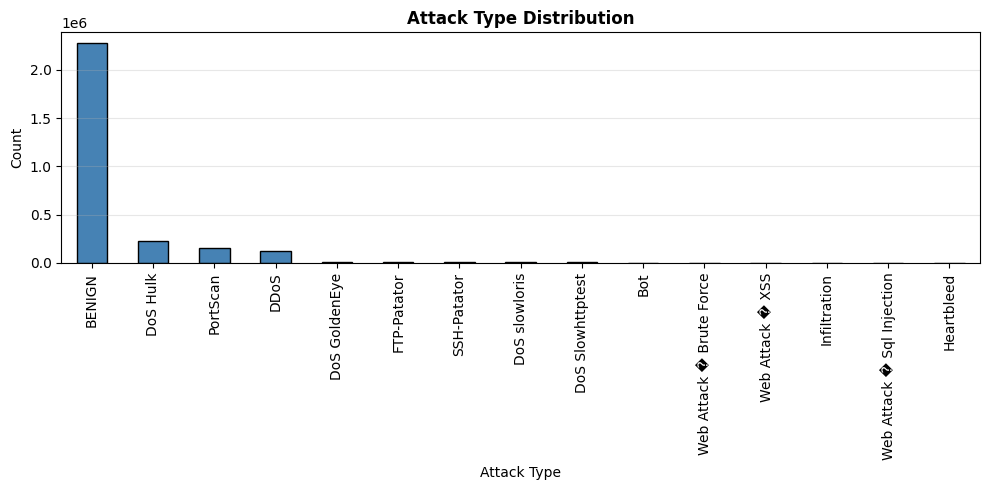


✅ EDA Complete


In [23]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(10, 5))
df['Label'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Attack Type Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Attack Type')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ EDA Complete")

In [24]:
# Print attack counts and percentages
print("\n🎯 ATTACK TYPE BREAKDOWN:")
print("=" * 80)

attack_counts = df['Label'].value_counts()
attack_percentages = df['Label'].value_counts(normalize=True) * 100

for attack_type in attack_counts.index:
    count = attack_counts[attack_type]
    percentage = attack_percentages[attack_type]
    print(f"{attack_type:20s}: {count:>10,} samples ({percentage:>6.2f}%)")

print("=" * 80)
print(f"{'TOTAL':20s}: {len(df):>10,} samples (100.00%)")


🎯 ATTACK TYPE BREAKDOWN:
BENIGN              :  2,273,097 samples ( 80.30%)
DoS Hulk            :    231,073 samples (  8.16%)
PortScan            :    158,930 samples (  5.61%)
DDoS                :    128,027 samples (  4.52%)
DoS GoldenEye       :     10,293 samples (  0.36%)
FTP-Patator         :      7,938 samples (  0.28%)
SSH-Patator         :      5,897 samples (  0.21%)
DoS slowloris       :      5,796 samples (  0.20%)
DoS Slowhttptest    :      5,499 samples (  0.19%)
Bot                 :      1,966 samples (  0.07%)
Web Attack � Brute Force:      1,507 samples (  0.05%)
Web Attack � XSS    :        652 samples (  0.02%)
Infiltration        :         36 samples (  0.00%)
Web Attack � Sql Injection:         21 samples (  0.00%)
Heartbleed          :         11 samples (  0.00%)
TOTAL               :  2,830,743 samples (100.00%)


Total samples: 2,415,219
Rare labels (count, pct):
 - Bot: 1949 (0.0807%)
 - Web Attack � Brute Force: 1426 (0.0590%)
 - Web Attack � XSS: 651 (0.0270%)
 - Infiltration: 36 (0.0015%)
 - Web Attack � Sql Injection: 20 (0.0008%)
 - Heartbleed: 11 (0.0005%)

Showing rare samples (limited to first 200 rows total)...

Label: Bot  |  Index: 536284  |  (sample 1)
Key features:
{'Destination Port': 8080, 'Flow Duration': 60202640, 'Total Fwd Packets': 9, 'Total Backward Packets': 9, 'Total Length of Fwd Packets': 322, 'Total Length of Bwd Packets': 256, 'Fwd Packet Length Mean': 35.77777778, 'Bwd Packet Length Mean': 28.44444444, 'Flow Bytes/s': 9.600907867, 'Flow Packets/s': 0.29899021, 'Flow IAT Mean': 3541331.765, 'Fwd IAT Mean': 6396441.875, 'Bwd IAT Mean': 7518953.625, 'Average Packet Size': 32.11111111, 'Fwd PSH Flags': 0, 'Bwd PSH Flags': 0, 'Fwd URG Flags': 0, 'Bwd URG Flags': 0, 'Label': 'Bot'}
No obvious quick flags detected — requires deeper feature-level or packet-level inspection.

## 2. Data Preprocessing and Cleaning

In [10]:
# Create a copy for processing
df_processed = df.copy()

print("\n🔧 DATA CLEANING STEPS:")
print("=" * 80)

# Step 0: Select 18 key features to reduce memory usage
# Full ISCX dataset has 78+ features, we select the most relevant ones
key_features = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Average Packet Size',
    'Fwd PSH Flags',
    'Bwd PSH Flags',
    'Fwd URG Flags',
    'Bwd URG Flags'
]

# Check which features exist in the dataset
available_features = [f for f in key_features if f in df_processed.columns]
print(f"\n0. Selecting key features to reduce memory usage:")
print(f"   Available key features: {len(available_features)}/18")
print(f"   Original shape: {df_processed.shape}")

# Use available features + Label
features_to_keep = available_features + ['Label']
df_processed = df_processed[features_to_keep]
print(f"   New shape (18 features + Label): {df_processed.shape}")
print(f"   Memory reduction: {(1 - df_processed.shape[1]/78)*100:.1f}%")

# Step 1: Remove duplicates
duplicates_before = df_processed.shape[0]
df_processed = df_processed.drop_duplicates()
duplicates_removed = duplicates_before - df_processed.shape[0]
print(f"\n1. Removed {duplicates_removed} duplicate rows")

# Step 2: Handle missing values
print(f"\n2. Handling missing values:")
for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        if df_processed[col].dtype in ['float64', 'int64']:
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
            print(f"   {col}: Filled with median")
        else:
            df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
            print(f"   {col}: Filled with mode")

if df_processed.isnull().sum().sum() == 0:
    print("   ✅ No missing values remaining")

# Step 3: Handle infinite values
print(f"\n3. Handling infinite values:")
for col in df_processed.select_dtypes(include=[np.number]).columns:
    inf_mask = np.isinf(df_processed[col])
    if inf_mask.sum() > 0:
        df_processed.loc[inf_mask, col] = 0
        print(f"   {col}: Replaced {inf_mask.sum()} infinite values")

print(f"\n4. Final dataset shape: {df_processed.shape}")
print(f"✅ Data cleaning complete")


🔧 DATA CLEANING STEPS:

0. Selecting key features to reduce memory usage:
   Available key features: 18/18
   Original shape: (2830743, 79)
   New shape (18 features + Label): (2830743, 19)
   Memory reduction: 75.6%

1. Removed 415524 duplicate rows

2. Handling missing values:
   Flow Bytes/s: Filled with median
   ✅ No missing values remaining

3. Handling infinite values:
   Flow Bytes/s: Replaced 1022 infinite values
   Flow Packets/s: Replaced 1284 infinite values

4. Final dataset shape: (2415219, 19)
✅ Data cleaning complete


## 3. Feature Engineering

In [32]:
print("\n⚙️  FEATURE ENGINEERING:")
print("=" * 80)

# Separate features and labels
X = df_processed.drop('Label', axis=1)
y = df_processed['Label']

print(f"\n1. Features shape: {X.shape}")
print(f"   Features: {list(X.columns)}")

print(f"\n2. Target variable distribution:")
print(f"   Unique classes: {y.nunique()}")
print(f"   Classes: {y.unique()}")

# Create label mapping for classification
label_map = {label: idx for idx, label in enumerate(sorted(y.unique()))}
reverse_map = {idx: label for label, idx in label_map.items()}

print(f"\n3. Label encoding:")
for label, idx in label_map.items():
    print(f"   {label}: {idx}")

y_encoded = y.map(label_map)

# Split data into train/validation/test with stratification
# 80% train, 10% validation, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n4. Train-Validation-Test Split:")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Validation set: {X_val.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")

print(f"\n✅ Feature engineering complete")


⚙️  FEATURE ENGINEERING:

1. Features shape: (2415219, 18)
   Features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Average Packet Size', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags']

2. Target variable distribution:
   Unique classes: 15
   Classes: ['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed']

3. Label encoding:
   BENIGN: 0
   Bot: 1
   DDoS: 2
   DoS GoldenEye: 3
   DoS Hulk: 4
   DoS Slowhttptest: 5
   DoS slowloris: 6
   FTP-Patator: 7
   Heartbleed: 8
   Infiltration: 9
   PortScan: 10
   SSH-Patator: 11
   Web Attack � Brute Force: 12
  

## 4. Feature Scaling and Normalization

In [36]:
print("\n📏 FEATURE SCALING:")
print("=" * 80)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n1. Before scaling:")
print(f"   Mean: {X_train.mean().values[:5]}...")
print(f"   Std:  {X_train.std().values[:5]}...")

print(f"\n2. After scaling (StandardScaler):")
print(f"   Mean: {X_train_scaled.mean(axis=0)[:5]}...")
print(f"   Std:  {X_train_scaled.std(axis=0)[:5]}...")

print(f"\n3. Scaler parameters saved for inference:")
print(f"   Mean: {scaler.mean_[:5]}...")
print(f"   Scale: {scaler.scale_[:5]}...")

# Convert to DataFrame for easier handling
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"\n✅ Feature scaling complete")


📏 FEATURE SCALING:

1. Before scaling:
   Mean: [8.87474267e+03 1.73056555e+07 1.03480663e+01 1.16519461e+01
 6.28531588e+02]...
   Std:  [1.91715521e+04 3.58220474e+07 7.85764647e+02 1.04517929e+03
 6.68442794e+03]...

2. After scaling (StandardScaler):
   Mean: [ 1.53863434e-17 -6.40975061e-17  1.19332420e-18  1.54451822e-18
 -5.02336164e-18]...
   Std:  [1. 1. 1. 1. 1.]...

3. Scaler parameters saved for inference:
   Mean: [8.87474267e+03 1.73056555e+07 1.03480663e+01 1.16519461e+01
 6.28531588e+02]...
   Scale: [1.91715471e+04 3.58220381e+07 7.85764443e+02 1.04517902e+03
 6.68442621e+03]...

✅ Feature scaling complete


## 5. Save Processed Data

In [37]:
import os

print("\n💾 SAVING PREPROCESSED DATA:")
print("=" * 80)

# Create datasets directory if it doesn't exist
os.makedirs('../datasets', exist_ok=True)

# Save training and test sets
joblib.dump(X_train_scaled_df, '../datasets/X_train_scaled.pkl')
joblib.dump(X_val_scaled_df, '../datasets/X_val_scaled.pkl')
joblib.dump(X_test_scaled_df, '../datasets/X_test_scaled.pkl')
joblib.dump(y_train, '../datasets/y_train.pkl')
joblib.dump(y_val, '../datasets/y_val.pkl')
joblib.dump(y_test, '../datasets/y_test.pkl')

print(f"\n1. Saved training/test sets:")
print(f"   X_train_scaled.pkl ({X_train_scaled_df.shape[0]} samples)")
print(f"   X_val_scaled.pkl ({X_val_scaled_df.shape[0]} samples)")
print(f"   X_test_scaled.pkl ({X_test_scaled_df.shape[0]} samples)")
print(f"   y_train.pkl ({len(y_train)} labels)")
print(f"   y_val.pkl ({len(y_val)} labels)")
print(f"   y_test.pkl ({len(y_test)} labels)")

# Save scaler for inference
joblib.dump(scaler, '../trained_models/scaler.pkl')
print(f"\n2. Saved feature scaler:")
print(f"   scaler.pkl (for inference layer)")

# Save label mappings as JSON for portability
with open('../trained_models/label_map.json', 'w', encoding='utf-8') as f:
    json.dump(label_map, f, indent=2)
with open('../trained_models/reverse_map.json', 'w', encoding='utf-8') as f:
    json.dump(reverse_map, f, indent=2)
print(f"\n3. Saved label mappings:")
print(f"   label_map.json (label -> index)")
print(f"   reverse_map.json (index -> label)")

# Save feature names as JSON so inference preserves column order
with open('../trained_models/feature_names.json', 'w', encoding='utf-8') as f:
    json.dump(X_train.columns.tolist(), f, indent=2)
print(f"\n4. Saved feature metadata:")
print(f"   feature_names.json (18 feature columns)")

print(f"\n✅ All preprocessed data saved successfully!")
print(f"\n📍 Location: ../trained_models/")
print(f"   Use these files in:")
print(f"   - 02_xgboost.ipynb")
print(f"   - 03_bert.ipynb")
print(f"   - 04_autoencoder.ipynb")


💾 SAVING PREPROCESSED DATA:

1. Saved training/test sets:
   X_train_scaled.pkl (1932175 samples)
   X_val_scaled.pkl (241522 samples)
   X_test_scaled.pkl (241522 samples)
   y_train.pkl (1932175 labels)
   y_val.pkl (241522 labels)
   y_test.pkl (241522 labels)

2. Saved feature scaler:
   scaler.pkl (for inference layer)

3. Saved label mappings:
   label_map.json (label -> index)
   reverse_map.json (index -> label)

4. Saved feature metadata:
   feature_names.json (18 feature columns)

✅ All preprocessed data saved successfully!

📍 Location: ../trained_models/
   Use these files in:
   - 02_xgboost.ipynb
   - 03_bert.ipynb
   - 04_autoencoder.ipynb


## Summary

**This notebook completes the preprocessing stage:**

✅ **Loaded** and combined the ISCX-IDS2017 CSV flow files  
✅ **Explored** data distributions and quality  
✅ **Cleaned** missing values and duplicates  
✅ **Engineered** 18 key features  
✅ **Scaled** features using `StandardScaler`  
✅ **Split** the cleaned data into stratified train/validation/test sets with a fixed random seed  
✅ **Saved** processed datasets and inference artifacts for model training  

**Saved artifacts:**
- `X_train_scaled.pkl`, `X_val_scaled.pkl`, `X_test_scaled.pkl`
- `y_train.pkl`, `y_val.pkl`, `y_test.pkl`
- `scaler.pkl`
- `feature_names.json`
- `label_map.json`, `reverse_map.json`

**Next Steps:** Run `02_xgboost.ipynb`, `03_bert.ipynb`, `04_autoencoder.ipynb`

---

*Preprocessing complete - May 27, 2026*